# Robotwin VV density plotting pipeline

Read `step_000/004/009/014/019/024.csv` from `data/26Aug9-Robotwin-VV-density/attn-density-vv-10-6/` and export the six-line Lingbot-VA Video-Video density plot to the matching directory under `figures/`.

## Imports and project root

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if all((candidate / name).is_dir() for name in ("notebooks", "data", "figures")):
            return candidate
    raise FileNotFoundError("Could not find the jupyter-plot project root")


PROJECT_ROOT = find_project_root()
print(f"project: {PROJECT_ROOT}")

project: /root/wenbiao_zhao/jupyter-plot


## Data and output configuration

In [2]:
WORKSET_NAME = "26Aug9-Robotwin-VV-density"
DATASET_NAME = "attn-density-vv-10-6"
EXPECTED_STEPS = ("step_000", "step_004", "step_009", "step_014", "step_019", "step_024")
INPUT_DIR = PROJECT_ROOT / "data" / WORKSET_NAME / DATASET_NAME
OUTPUT_DIR = PROJECT_ROOT / "figures" / WORKSET_NAME
OUTPUT_STEM = OUTPUT_DIR / "lingbot_va_video_video_density"
OUTPUT_FORMATS = ("png", "pdf")
DPI = 300

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"input : {INPUT_DIR}")
print(f"output: {OUTPUT_DIR}")

input : /root/wenbiao_zhao/jupyter-plot/data/26Aug9-Robotwin-VV-density/attn-density-vv-10-6
output: /root/wenbiao_zhao/jupyter-plot/figures/26Aug9-Robotwin-VV-density


## Plot configuration

In [3]:
TITLE = "Lingbot-VA (Video-Video)"
X_LABEL = "Layer"
Y_LABEL = "Sparsity"
Y_LIMITS = (0.0, 1.0)
FIGSIZE = (5.2, 3.5)
LINE_WIDTH = 1.9
X_GRID_STEP = 5
SHOW_LEGEND = True
COLORS = ("#D95F5F", "#4C91C6", "#E5A83A", "#55A868", "#8172B3", "#C76E9A")

## Load and validate the density tables

In [4]:
CSV_PATHS = [INPUT_DIR / f"{step}.csv" for step in EXPECTED_STEPS]
missing_paths = [path for path in CSV_PATHS if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f"Missing density CSVs: {[path.name for path in missing_paths]}")

tables = []
for csv_path in CSV_PATHS:
    table = pd.read_csv(csv_path)
    missing_columns = {"layer", "density"} - set(table.columns)
    if missing_columns:
        raise ValueError(f"{csv_path.name}: missing columns {sorted(missing_columns)}")
    table = table[["layer", "density"]].copy()
    table["layer"] = pd.to_numeric(table["layer"], errors="raise")
    table["density"] = pd.to_numeric(table["density"], errors="raise")
    if table["layer"].duplicated().any():
        raise ValueError(f"{csv_path.name}: duplicate layer indices")
    if not np.isfinite(table[["layer", "density"]].to_numpy()).all():
        raise ValueError(f"{csv_path.name}: non-finite layer or density value")
    if not table["density"].between(*Y_LIMITS).all():
        raise ValueError(f"{csv_path.name}: density must lie within {Y_LIMITS}")
    table["step"] = csv_path.stem
    tables.append(table.sort_values("layer"))

DENSITY_TABLE = pd.concat(tables, ignore_index=True)
if tuple(DENSITY_TABLE["step"].drop_duplicates()) != EXPECTED_STEPS:
    raise ValueError("Density step order does not match EXPECTED_STEPS")
print(f"loaded {len(CSV_PATHS)} CSV files and {len(DENSITY_TABLE)} rows")
display(DENSITY_TABLE.pivot(index="layer", columns="step", values="density"))

loaded 6 CSV files and 180 rows


step,step_000,step_004,step_009,step_014,step_019,step_024
layer,,,,,,
0,0.440762,0.454806,0.462649,0.465283,0.463094,0.452781
1,0.553612,0.595971,0.607998,0.597527,0.579861,0.545909
2,0.586558,0.604176,0.606575,0.600074,0.585469,0.541483
3,0.553781,0.557408,0.555373,0.550448,0.543078,0.513502
4,0.543530,0.549139,0.552735,0.551337,0.549677,0.542020
5,0.531080,0.541548,0.541701,0.537201,0.534456,0.524874
6,0.614676,0.617907,0.616861,0.613886,0.606813,0.582610
7,0.639321,0.638113,0.637301,0.637054,0.637335,0.626440
8,0.616586,0.620382,0.620050,0.618778,0.618163,0.610056


## Draw and export the figure

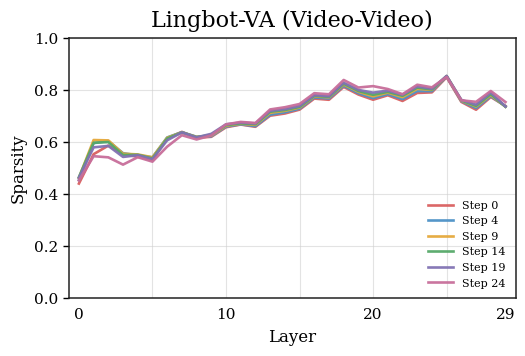

/root/wenbiao_zhao/jupyter-plot/figures/26Aug9-Robotwin-VV-density/lingbot_va_video_video_density.png
/root/wenbiao_zhao/jupyter-plot/figures/26Aug9-Robotwin-VV-density/lingbot_va_video_video_density.pdf


In [5]:
mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.titlesize": 16,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.linewidth": 1.1,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

fig, ax = plt.subplots(figsize=FIGSIZE)
for index, (step, table) in enumerate(DENSITY_TABLE.groupby("step", sort=True)):
    ax.plot(
        table["layer"],
        table["density"],
        color=COLORS[index % len(COLORS)],
        linewidth=LINE_WIDTH,
        alpha=0.95,
        label=f"Step {int(step.split('_')[1])}",
    )

layer_min = int(DENSITY_TABLE["layer"].min())
layer_max = int(DENSITY_TABLE["layer"].max())
layer_ticks = list(range(layer_min, layer_max + 1, 10))
if layer_max not in layer_ticks:
    layer_ticks.append(layer_max)
ax.set_xlim(layer_min - 0.7, layer_max + 0.7)
ax.set_xticks(layer_ticks)
ax.set_ylim(*Y_LIMITS)
ax.set_yticks(np.linspace(Y_LIMITS[0], Y_LIMITS[1], 6))
ax.set_title(TITLE, pad=8)
ax.set_xlabel(X_LABEL, labelpad=5)
ax.set_ylabel(Y_LABEL, labelpad=5)
ax.grid(False)
ax.yaxis.grid(True, color="#CFCFCF", linewidth=0.8, alpha=0.58)
first_grid_layer = ((layer_min // X_GRID_STEP) + 1) * X_GRID_STEP
for grid_layer in range(first_grid_layer, layer_max, X_GRID_STEP):
    ax.axvline(grid_layer, color="#CFCFCF", linewidth=0.8, alpha=0.58, zorder=1.5)
ax.set_axisbelow(True)
ax.tick_params(axis="x", direction="out", width=0, length=0, pad=7)
ax.tick_params(axis="y", direction="out", width=1.0, length=4)
for spine in ax.spines.values():
    spine.set_color("#222222")
    spine.set_linewidth(1.1)
if SHOW_LEGEND:
    ax.legend(
        frameon=False,
        fontsize=8,
        loc="lower right",
        handlelength=2.3,
    )

fig.tight_layout(pad=0.45)
SAVED_PATHS = []
for extension in OUTPUT_FORMATS:
    output_path = OUTPUT_STEM.with_suffix(f".{extension}")
    fig.savefig(output_path, dpi=DPI, bbox_inches="tight", pad_inches=0.03)
    SAVED_PATHS.append(output_path)
plt.show()
print(*SAVED_PATHS, sep="\n")